# J1.1: gate криволинейного sliding representation

Notebook читает frozen synthetic batch с известной конечной геометрией. Он проверяет, что отдельные lung/body transforms сохраняют advected contact и tangential slip на кривой поверхности, а также распознают два заранее заданных отрицательных контроля. КТ и expert landmarks не используются.

**Техническое воспроизведение, 14.09.2026.** Ноутбук сохраняет историческую постановку и ограничения. Повторное исполнение проверяет расчёты и отображение; оно не меняет научный статус ветки. Тяжёлые результаты читаются из сохранённых пакетов с исходными проверками целостности. Источники и конфигурации используются из этой папки проекта.

In [1]:
# Portable execution support; scientific sources remain in this checkout.
import os
import sys
from pathlib import Path
_start = Path(os.environ.get("BREATH_NOTEBOOK_DIR", Path.cwd())).resolve()
_support = next((folder for parent in (_start, *_start.parents)
                 for folder in (parent, parent / "notebooks", parent / "breath geometry/notebooks")
                 if (folder / "execution_support.py").is_file()), None)
if _support is None:
    raise FileNotFoundError("Не найден notebooks/execution_support.py")
sys.path.insert(0, str(_support))
from execution_support import roots, copdgene_case_dir, lungct_input
REPO_ROOT, ARTIFACT_ROOT = roots()
repo_root = REPO_ROOT


In [2]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

result_root = ARTIFACT_ROOT / "results" / "piecewise_svf_j11_representation_gate_v1"
config_path = (
    repo_root / "configs" / "piecewise_svf_j11_representation_gate_v1.json"
)
manifest_path = result_root / "manifest.json"

config = json.loads(config_path.read_text(encoding="utf-8"))
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
summary = pd.read_csv(result_root / "summary.csv")

def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest().upper()

hash_checks = {
    "config": sha256(config_path) == manifest["config"]["sha256"],
    "summary": sha256(result_root / "summary.csv")
    == manifest["summary_sha256"],
}
for name, expected in manifest["field_sha256"].items():
    hash_checks[f"field:{name}"] = sha256(result_root / name) == expected
for name, expected in manifest["record_sha256"].items():
    hash_checks[f"record:{name}"] = sha256(result_root / name) == expected

if not all(hash_checks.values()):
    raise RuntimeError("Checksum batch-артефактов не совпадает с manifest")
if manifest["protocol_version"] != config["protocol_version"]:
    raise RuntimeError("Protocol version в config и manifest различается")

display(pd.Series(hash_checks, name="sha256_ok").to_frame())
display(
    pd.Series(
        {
            "protocol": manifest["protocol_version"],
            "code_version": manifest["code_version"],
            "positive": (
                f"{manifest['positive_pass_count']}/"
                f"{manifest['positive_case_count']}"
            ),
            "negative controls": (
                f"{manifest['negative_control_recognized_count']}/"
                f"{manifest['negative_control_count']}"
            ),
            "all signatures": manifest["all_expected_signatures_pass"],
        },
        name="manifest",
    ).to_frame()
)

,sha256_ok
config,True
summary,True
field:curved_counter_rotation.npz,True
field:scaled_longitudinal_twist.npz,True
field:global_glued_control.npz,True
field:posthoc_fixed_normal_euler_control.npz,True
record:curved_counter_rotation.json,True
record:scaled_longitudinal_twist.json,True
record:global_glued_control.json,True
record:posthoc_fixed_normal_euler_control.json,True


,manifest
protocol,piecewise-svf-j1.1-representation-v1
code_version,21d04f19b67b2ee2967f05b552c9c2b67b119289
positive,2/2
negative controls,2/2
all signatures,True


## Матрица gate и сигнатур

`candidate_full_gate_pass` должен быть истинным только для положительных cases. Для контролей важна более строгая проверка ожидаемой причины: global field теряет slip при сохранённых topology/contact, а fixed-normal Euler control сохраняет topology и проходит scalar normal screen, но нарушает конечный surface contact.

In [3]:
gate_columns = [
    "case_id",
    "role",
    "topology_pass",
    "contact_pass",
    "slip_pass",
    "candidate_full_gate_pass",
    "candidate_gate_reasons",
    "expected_signature_pass",
    "expected_signature_reasons",
]
display(summary[gate_columns].set_index("case_id"))

metric_columns = [
    "case_id",
    "fixed_normal_mismatch_p95_mm",
    "lung_target_surface_abs_p95_mm",
    "body_target_surface_abs_p95_mm",
    "target_surface_coverage_min",
    "interregional_surface_p95_mm",
    "gap_fraction",
    "collision_fraction",
    "tangential_slip_truth_median_mm",
    "tangential_slip_observed_median_mm",
    "tangential_slip_error_mm",
]
display(summary[metric_columns].set_index("case_id"))

,role,topology_pass,contact_pass,slip_pass,candidate_full_gate_pass,candidate_gate_reasons,expected_signature_pass,expected_signature_reasons
case_id,,,,,,,,
curved_counter_rotation,positive,True,True,True,True,NaN,True,NaN
scaled_longitudinal_twist,positive,True,True,True,True,NaN,True,NaN
global_glued_control,negative_global_glued,True,True,False,False,endpoint_p95;tangential_slip,True,NaN
posthoc_fixed_normal_euler_control,negative_posthoc_fixed_normal,True,False,True,False,endpoint_p95;round_trip_p95;jacobian_p01;targe...,True,NaN


,fixed_normal_mismatch_p95_mm,lung_target_surface_abs_p95_mm,body_target_surface_abs_p95_mm,target_surface_coverage_min,interregional_surface_p95_mm,gap_fraction,collision_fraction,tangential_slip_truth_median_mm,tangential_slip_observed_median_mm,tangential_slip_error_mm
case_id,,,,,,,,,,
curved_counter_rotation,2.091283e-01,0.001096,2.740642e-04,1.000000,0.119374,0.0,0.000000,3.783788,3.783906,0.000118
scaled_longitudinal_twist,4.438320e-02,0.000185,8.724134e-05,1.000000,0.441973,0.0,0.000000,1.631017,1.630912,0.000105
global_glued_control,0.000000e+00,0.000069,6.850973e-05,1.000000,0.000000,0.0,0.000000,3.783788,0.000000,3.783788
posthoc_fixed_normal_euler_control,5.406021e-08,0.352387,6.066896e-15,0.204082,0.536400,0.0,0.397959,2.840825,2.844663,0.003839


## Fixed-normal screen и конечный contact — не одно и то же

Ниже scalar normal mismatch на исходной поверхности сравнивается с p95 signed distance уже деформированной поверхности. Валидное скольжение может иметь ненулевую pointwise fixed-normal разность из-за конечного поворота, а касательный Euler-шаг может иметь почти нулевую normal разность и всё равно выйти за кривую поверхность.

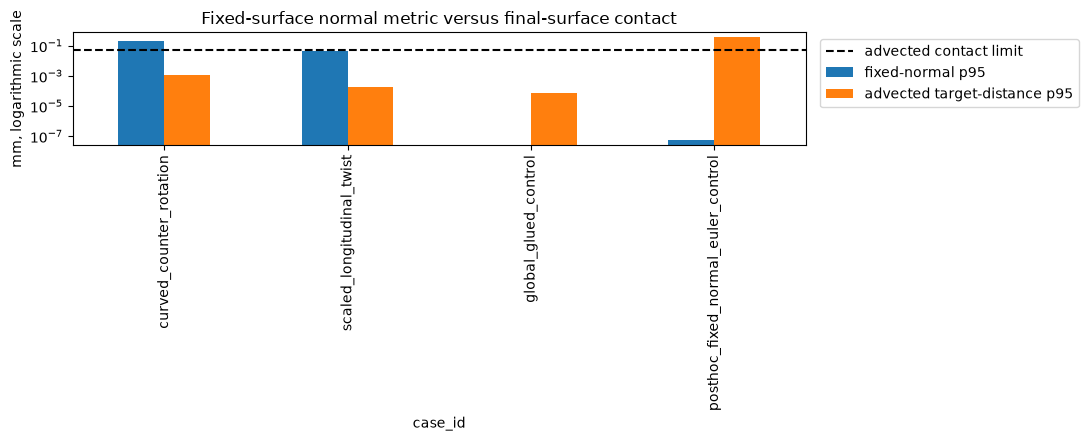

In [4]:
comparison = summary.set_index("case_id")[
    [
        "fixed_normal_mismatch_p95_mm",
        "lung_target_surface_abs_p95_mm",
    ]
].rename(
    columns={
        "fixed_normal_mismatch_p95_mm": "fixed-normal p95",
        "lung_target_surface_abs_p95_mm": "advected target-distance p95",
    }
)
axis = comparison.plot.bar(figsize=(11, 4.5), logy=True)
axis.axhline(
    config["thresholds"]["target_surface_abs_p95_max_mm"],
    color="black",
    linestyle="--",
    label="advected contact limit",
)
axis.set_ylabel("mm, logarithmic scale")
axis.set_title("Fixed-surface normal metric versus final-surface contact")
axis.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

## Пространственная карта gap/collision

Signed distance показан на параметрической сетке интерфейса: отрицательное значение — gap внутрь target surface, положительное — collision наружу. Один цветовой диапазон используется для обоих positive cases; для post-hoc контроля диапазон расширен отдельно, чтобы не скрывать ошибку.

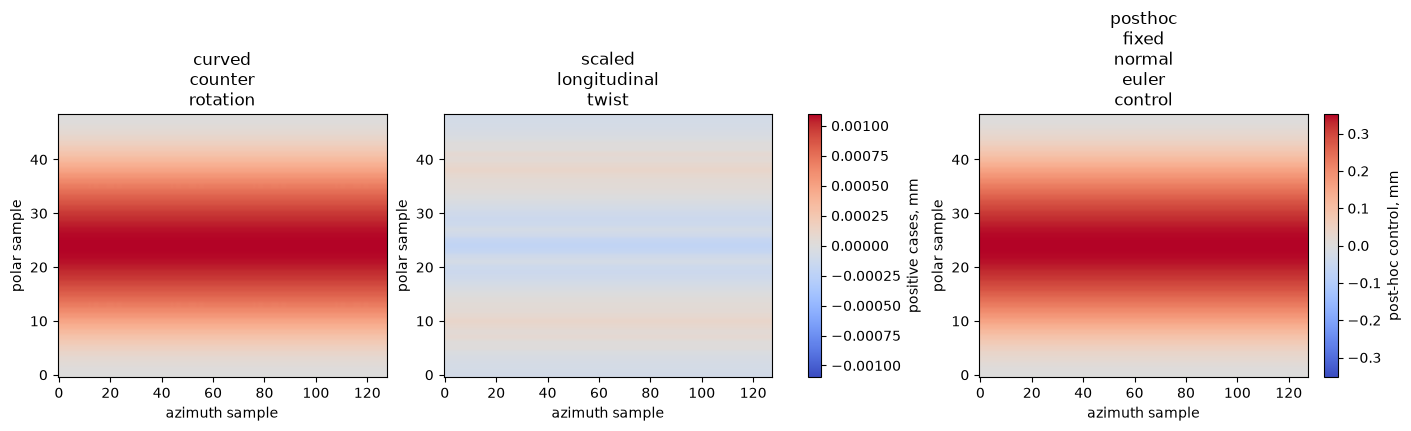

In [5]:
polar = config["interface"]["polar_sample_count"]
azimuth = config["interface"]["azimuth_sample_count"]
case_ids = [
    "curved_counter_rotation",
    "scaled_longitudinal_twist",
    "posthoc_fixed_normal_euler_control",
]
signed_maps = {}
for case_id in case_ids:
    artifact = np.load(result_root / f"{case_id}.npz", allow_pickle=False)
    signed_maps[case_id] = artifact["lung_target_signed_distance_mm"].reshape(
        polar,
        azimuth,
    )

positive_limit = max(
    float(np.abs(signed_maps[case_id]).max())
    for case_id in case_ids[:2]
)
control_limit = float(np.abs(signed_maps[case_ids[2]]).max())
figure, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
images = []
for index, (axis, case_id) in enumerate(zip(axes, case_ids, strict=True)):
    limit = positive_limit if index < 2 else control_limit
    image = axis.imshow(
        signed_maps[case_id],
        origin="lower",
        aspect="auto",
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit,
    )
    images.append(image)
    axis.set_title(case_id.replace("_", "\n"))
    axis.set_xlabel("azimuth sample")
    axis.set_ylabel("polar sample")
figure.colorbar(images[0], ax=axes[:2], label="positive cases, mm")
figure.colorbar(images[2], ax=axes[2], label="post-hoc control, mm")
plt.show()

In [6]:
if not manifest["all_expected_signatures_pass"]:
    raise RuntimeError("J1.1 не прошёл frozen expected-signature gate")
positive = summary[summary["role"] == "positive"]
if not bool(positive["candidate_full_gate_pass"].all()):
    raise RuntimeError("Не все положительные J1.1 cases прошли полный gate")

counter = summary.set_index("case_id").loc["curved_counter_rotation"]
posthoc = summary.set_index("case_id").loc[
    "posthoc_fixed_normal_euler_control"
]
display(
    Markdown(
        "**J1.1 PASS: positive 2/2, controls 2/2.** "
        f"Валидный counter-rotation имеет fixed-normal p95 "
        f"{counter['fixed_normal_mismatch_p95_mm']:.3f} мм при полном contact PASS. "
        f"Post-hoc control имеет fixed-normal p95 "
        f"{posthoc['fixed_normal_mismatch_p95_mm']:.2e} мм, но collision fraction "
        f"{100 * posthoc['collision_fraction']:.1f}% и coverage "
        f"{100 * posthoc['target_surface_coverage_min']:.1f}%. Следовательно, "
        "fixed-normal equality не является ни достаточным, ни необходимым критерием "
        "конечного контакта на кривой поверхности. Следующий шаг — J1.2 joint "
        "synthetic image optimizer с advected-surface loss и topology rejection. "
        "Gate 1L/1B и парные карты тканей остаются закрыты."
    )
)

**J1.1 PASS: positive 2/2, controls 2/2.** Валидный counter-rotation имеет fixed-normal p95 0.209 мм при полном contact PASS. Post-hoc control имеет fixed-normal p95 5.41e-08 мм, но collision fraction 39.8% и coverage 20.4%. Следовательно, fixed-normal equality не является ни достаточным, ни необходимым критерием конечного контакта на кривой поверхности. Следующий шаг — J1.2 joint synthetic image optimizer с advected-surface loss и topology rejection. Gate 1L/1B и парные карты тканей остаются закрыты.